<html>
<div style="
background:linear-gradient(135deg,  #0F4C81, rgb(174, 38, 202));
padding:35px;
border-radius:15px;
color:white;
margin-bottom:35px;
">

<h2 style="margin:0;">
Lung Adenocarcinoma (LUAD) Transcriptomic Analysis for Candidate Biomarker Identification🫁
</h2>


<p style="margin-top:20px;
        font-size:16px;
        opacity:.9;">
Sahel Sepehri • 2026
</p>

</div>
</html>

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Introduction
</h2>

</div>

> - Lung adenocarcinoma (LUAD) is the most common subtype of non-small cell lung cancer and remains one of the leading causes of cancer-related mortality worldwide.
> - Transcriptomic analysis enables the identification of differentially expressed genes associated with tumor development and provides valuable insights into molecular mechanisms and potential therapeutic targets.
> - In this project, publicly available microarray data from the GEO database were analyzed using reproducible R-based bioinformatics workflows.


> **Project Objectives:**
> This project aims to:
>- Analyze LUAD gene expression profiles
>- Identify differentially expressed genes
>- Construct a protein-protein interaction network
>- Identify hub genes
>- Perform functional enrichment analysis
>- Evaluate prognostic significance
>- Validate gene expression


> **Dataset:**
> - Dataset: GSE43458
> - Platform: GPL6244

>**Samples:**
>- 80 LUAD
>- 30 Normal Lung


<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Overall Workflow
</h2>

</div>



<style>
.figure img{
    width:50%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>

<div class="figure">

<img src="">

</div>


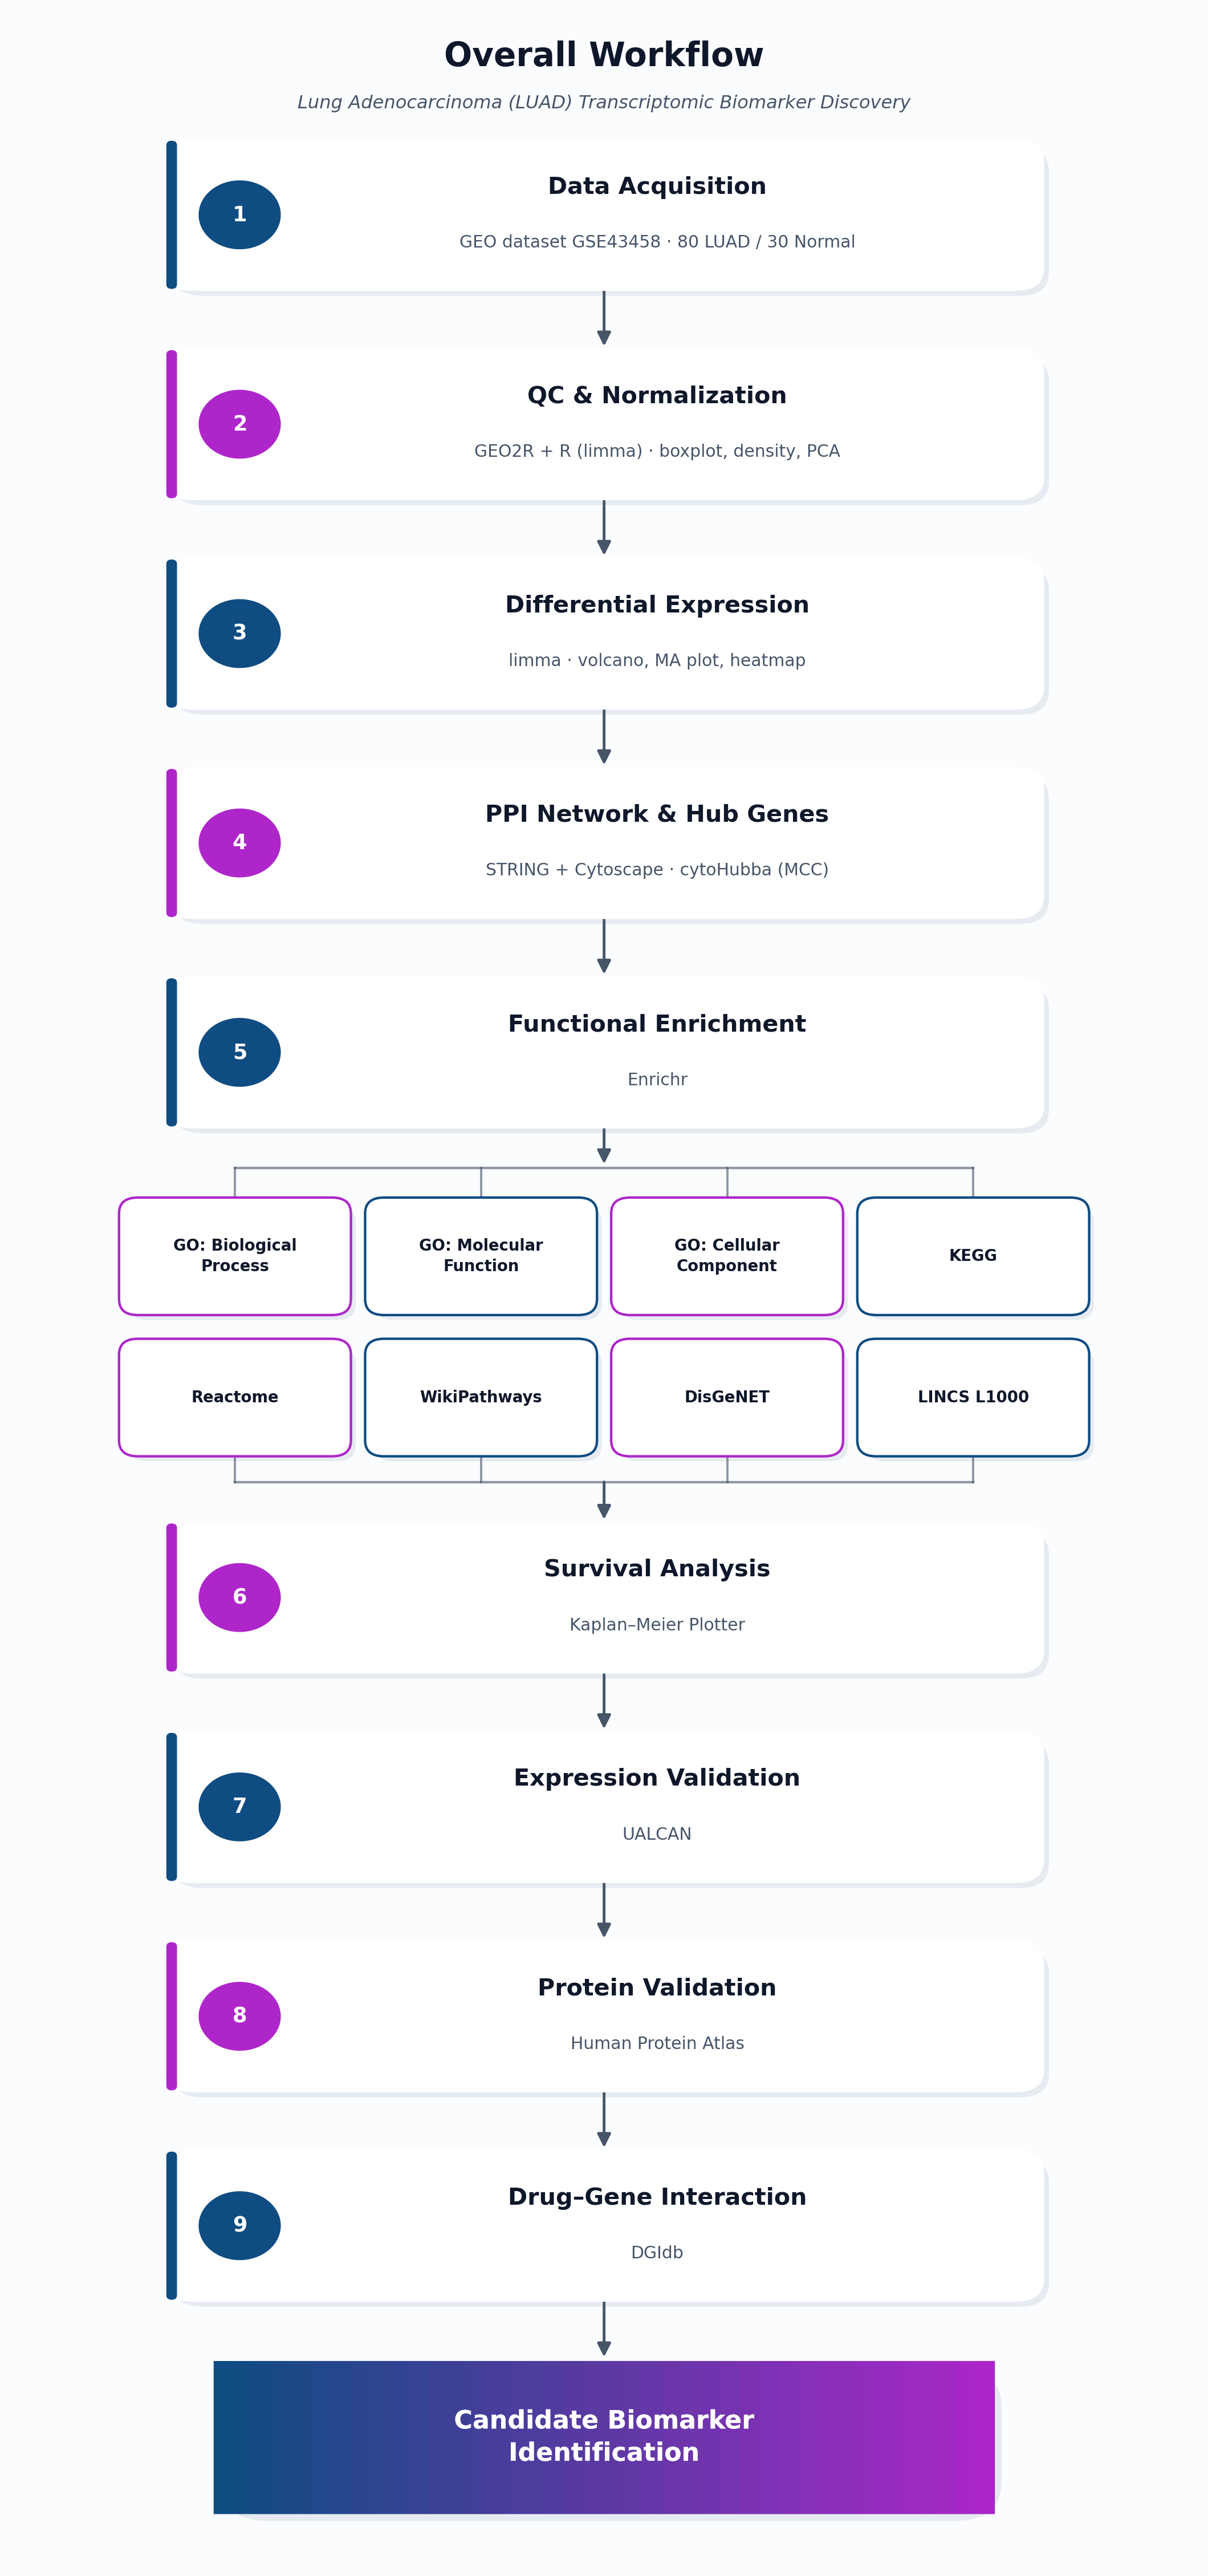

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Dataset Overview
</h2>

</div>

> 1. The gene expression dataset **`GSE43458`** was obtained from the **`NCBI Gene Expression Omnibus (GEO)`** database. 
> 2. This dataset contains microarray gene expression profiles from **`110 human lung tissue samples`**, including **`80 lung adenocarcinoma (LUAD)`** samples and **`30 normal lung tissues`**.
> 3. The expression data were generated using the **`Affymetrix Human Gene 1.0 ST Array (GPL6244)`** platform.
> 4. The dataset was selected because it provides a sufficiently large number of tumor and normal samples for differential gene expression analysis.


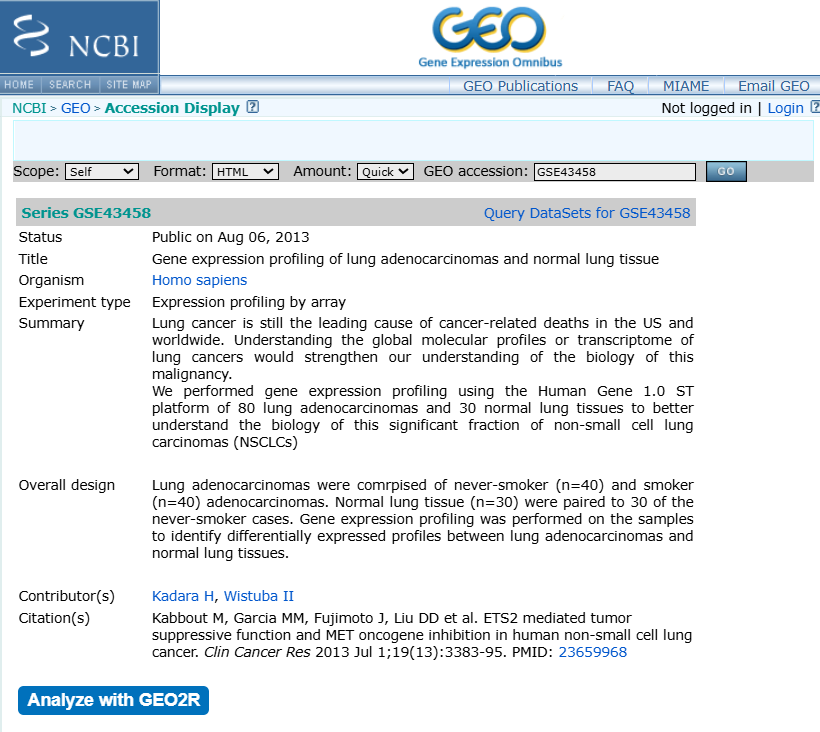

| Feature            | Description                                      |
| ------------------ | ------------------------------------------------ |
| Dataset            | GSE43458                                         |
| Database           | NCBI GEO                                         |
| Organism           | Homo sapiens                                  |
| Platform           | GPL6244 (Affymetrix Human Gene 1.0 ST Array)     |
| Total Samples      | 110                                              |
| LUAD Samples       | 80                                               |
| Normal Samples     | 30                                               |
| Analysis Tool      | GEO2R                                            |
| Filtering Criteria | Adjusted P-value < 0.05, logFC > 1, logFC < -1 |


---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Sample Group Definition (Tumor vs Normal)
</h2>


</div>



> 1. Before performing differential expression analysis, the samples were assigned to two experimental groups in **`GEO2R`**.
> 2. The 80 lung adenocarcinoma samples were assigned to the **`Tumor group`**, while the 30 normal lung tissue samples were assigned to the **`Normal group`**.
> 3. These group definitions were used by GEO2R to compare gene expression levels between tumor and normal tissues.

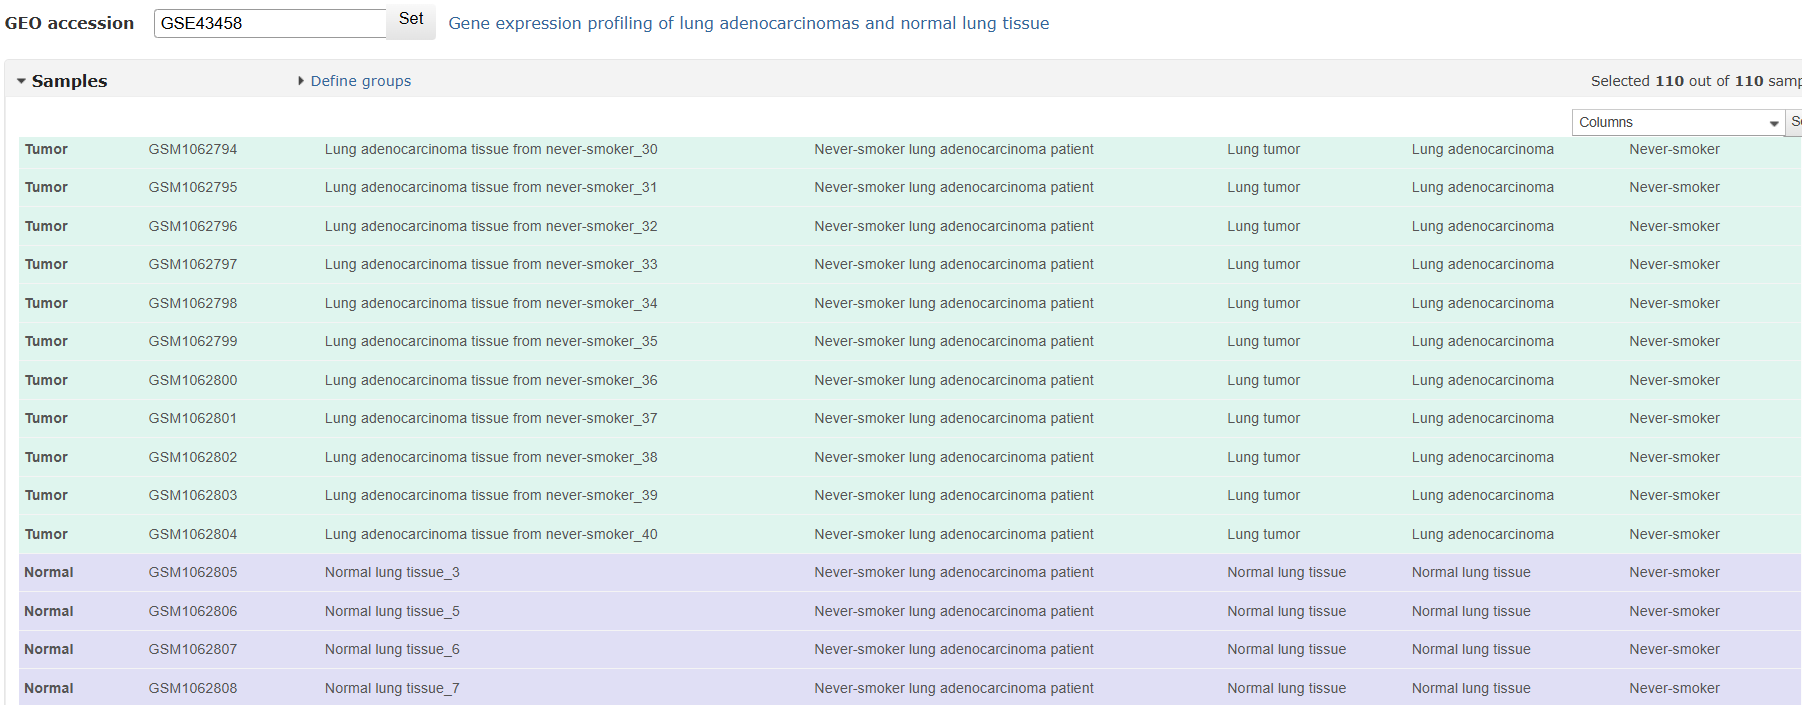

---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Exploratory Analysis using GEO2R
</h2>


</div>


> **Input:** GSE43458 (80 LUAD tumor + 30 normal lung tissues)
> 
> **Tool:** GEO2R
> 
> **Output:**  
>- List of differentially expressed genes  
>- Volcano plot and statistical table
> 1. Differential expression analysis was performed using the **`GEO2R`** web tool to calculate log fold change (logFC)and adjusted P-values for each gene.
> 2. The resulting table was exported to **`Microsoft Excel`**, where statistical filtering was applied using an **`adjusted P-value < 0.05`**. Genes with **`logFC > 1`** were classified as **`up-regulated`**, whereas genes with **`logFC < -1`** were classified as **`down-regulated`**.
> 3. The filtered gene lists were used for subsequent analyses.


GEO2R was initially used as an exploratory tool to inspect differential expression patterns and obtain a preliminary list of differentially expressed genes.

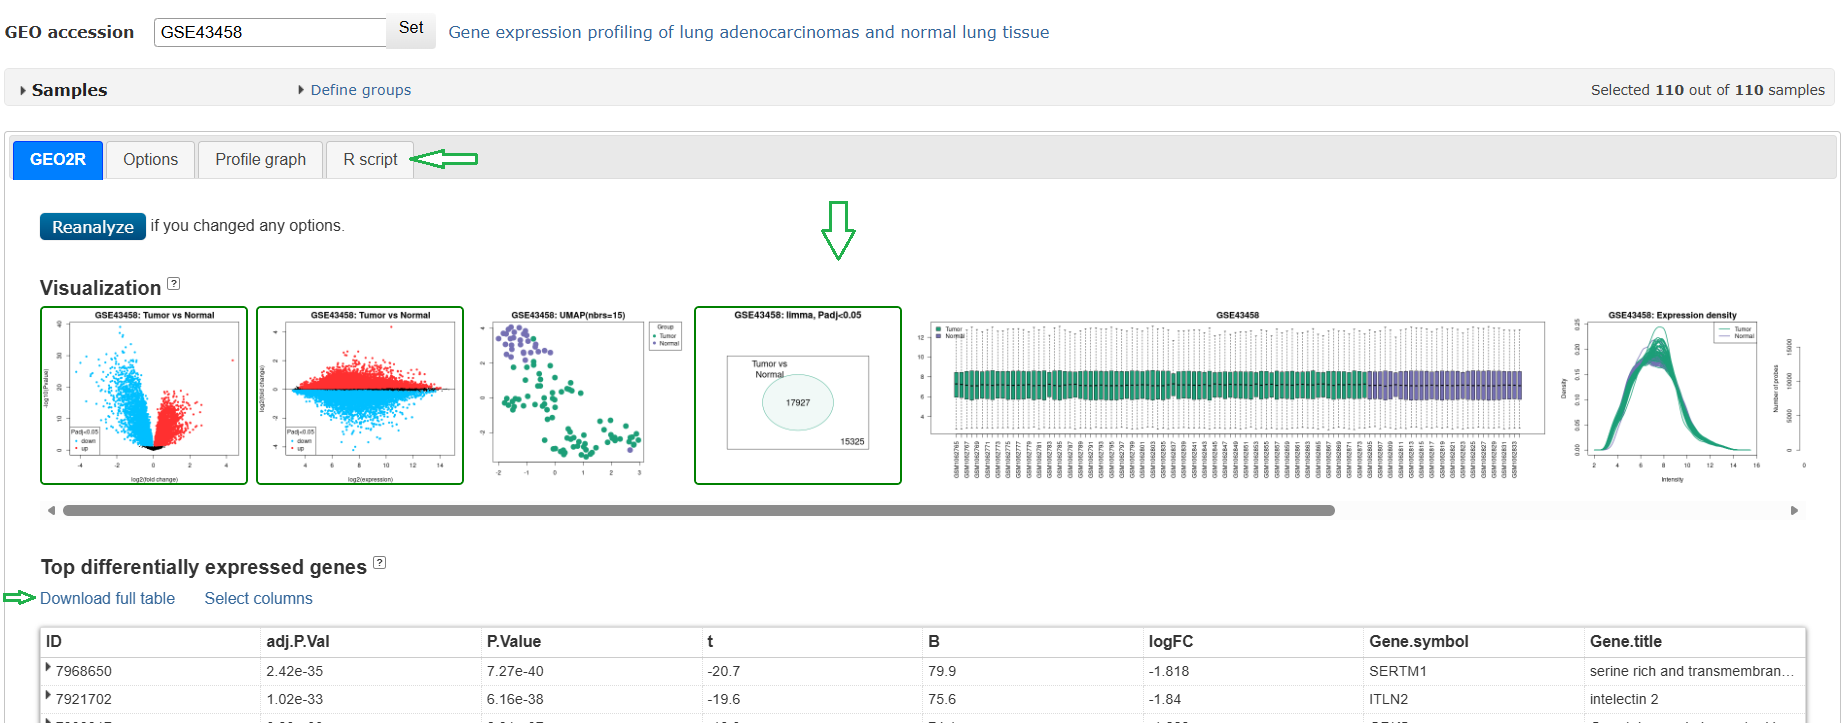

---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Reproducible Analysis in R
</h2>

</div>



<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Load Required Packages
</h4>
</div>


> - The analysis was performed in R using several packages for data retrieval, statistical analysis, and visualization.
> - `GEOquery` was used to retrieve the dataset from GEO, `limma` was used for differential expression analysis, and `ggplot2` and `pheatmap` were used for visualization.

```r

library(GEOquery)
library(limma)
library(ggplot2)
library(pheatmap)

````

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Download GEO Dataset
</h4>
</div>


> - The GSE43458 dataset was obtained from the NCBI Gene Expression Omnibus (GEO) database.
> - The dataset contains gene expression measurements from human lung tissue samples, including LUAD tumor and normal lung samples.

```r
# Download the GSE43458 dataset from GEO
gset <- getGEO(
  "GSE43458",
  GSEMatrix = TRUE,
  AnnotGPL = TRUE
)[[1]]

```


<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Explore Dataset
</h4>
</div>

> - I first examined the structure and dimensions of the expression matrix.
> - The rows represent probes/features and the columns represent individual samples.

```r

# Extract the expression matrix from the GEO object
expr <- exprs(gset)

# Check the dimensions of the expression matrix
dim(expr)

# Display the first five samples
head(expr[, 1:5])

# Display the first few feature IDs
head(rownames(expr))

# Display the first few sample IDs
head(colnames(expr))

  
```

Expression Matrix
>- The expression data were extracted from the GEO dataset using `exprs()`.
>- The resulting expression matrix contains `33,252 features` measured across `110 samples`.
>- Rows represent expression features, while columns represent individual biological samples.
>- The feature and sample identifiers were inspected to verify the structure of the dataset before downstream analysis.

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Sample Annotation
</h4>
</div>

>- The biological condition of each sample is stored in the GEO metadata.
>- I inspected the sample characteristics to identify the tumor and normal tissue groups.

```r
# Examine the biological characteristics recorded for each sample
table(pData(gset)$characteristics_ch1)

# Inspect the sample metadata
head(pData(gset))

# List the available metadata fields
colnames(pData(gset))
```

> - Sample-level biological information was obtained from the GEO metadata using `pData()`.
> - The sample characteristics were examined to determine the biological condition of each sample and to verify the distribution of tumor and normal tissues before downstream analysis.


<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Create Sample Groups
</h4>
</div>


> - The samples were divided into two groups based on their tissue type.
> - Samples from lung tumor tissue were assigned to the `Tumor` group, while the remaining normal lung tissue samples were assigned to the `Normal` group.
> - These groups were then used for the statistical comparison.

```r

# Assign samples to Tumor or Normal groups
group <- ifelse(
  pData(gset)$characteristics_ch1 == "tissue: Lung tumor",
  "Tumor",
  "Normal"
)

# Convert the group variable to a categorical factor
group <- factor(group)

# Check the number of samples in each group
table(group)
```
- Lung tumor tissue : 80
- Normal lung tissue : 30
                                               

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Quality Control (R)
</h2>
</div>

> - Before performing differential expression analysis, I examined the distribution and overall structure of the expression data.
> - Before interpreting biological differences, we want to make sure that the observed variation is not obviously driven by technical problems or unusual samples.
> Three approaches were used:
> - `Boxplot` to compare expression distributions across samples
> - `Density plot` to examine the overall distribution of expression values
> - `PCA` to examine the main sources of variation between samples



<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Boxplot
</div>


> - The boxplot was used to `compare the distribution of expression values across samples`.
> - Similar distributions across samples suggest that there are no obvious samples with strongly different overall expression distributions.

```r
# Compare the overall expression distributions across samples
boxplot(
        expr,
         outline = FALSE, # Hide individual outlier points
          las = 2,        # Rotate sample labels
           col = "lightblue",
        main = "Expression Value Distribution"
        )
```
<style>
.figure img{
    width:50%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>

<div class="figure">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/Boxplot.png?raw=true">
</div>

The boxplot allows us to compare:
- median
- interquartile range
- overall distribution
across samples.


<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Density Plot
</div>
 

> - The density plot provides another view of the distribution of expression values across samples.
> - Similar density curves suggest that the samples have comparable overall expression distributions.


```r
# Examine the distribution of expression values across samples
plotDensities(
    expr,
     main = "Density Plot of Expression Values")
```
<style>
.figure img{
    width:50%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>


<div class="figure">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/Density%20Plot.png?raw=true">


</div>





<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Principal Component Analysis (PCA)
</div>

> - PCA was used to summarize the major sources of variation in the expression data.
> - Each point represents `one sample`. Samples with similar expression profiles are expected to appear closer together.
> - The samples were colored according to their biological group to examine whether tumor and normal samples show separation.



 ```r
# Perform PCA on the samples
# Transpose the expression matrix so that samples are rows
pca <- prcomp(
  t(expr),
  scale. = TRUE
)

# Plot the first two principal components
plot(
  pca$x[, 1],
  pca$x[, 2],
  col = group,
  pch = 19,
  xlab = "PC1",
  ylab = "PC2",
  main = "Principal Component Analysis"
)

# Add sample group information to the plot
legend(
  "topright",
  legend = levels(group),
  col = 1:2,
  pch = 19
)
```
<style>
.figure img{
    width:50%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>

<div class="figure">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/PCA.png?raw=true">


</div>

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Differential Expression Analysis 
</h2>
</div>

> - The goal of this analysis is to identify genes that are `expressed differently between LUAD tumor samples and normal lung tissue`.
> - I used the `limma` package to model gene expression differences between the two groups.
> - The main comparison in this analysis is: **Tumor vs Normal**

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Design Matrix
</div>

> - First, I created a design matrix to tell the statistical model which samples belong to the Tumor group and which belong to the Normal group.
> - Each row represents one sample, and each column represents one group.

```r
# Create a design matrix from the Tumor/Normal groups.
# ~0 + group creates one column for each group instead of an intercept.
design <- model.matrix(~0 + group)

# Rename the columns using the actual group names:
# Tumor and Normal
colnames(design) <- levels(group)

# Display the design matrix
design
```

``` text
    Normal Tumor
1        0     1
2        0     1
3        0     1
4        0     1
5        0     1
6        0     1
7        0     1
8        0     1
9        0     1
10       0     1
11       0     1
12       0     1
13       0     1
14       0     1
15       0     1
16       0     1
17       0     1
18       0     1
19       0     1
20       0     1
21       0     1
22       0     1
23       0     1
24       0     1
25       0     1
26       0     1
27       0     1
28       0     1
29       0     1
30       0     1
31       0     1
32       0     1
33       0     1
34       0     1
35       0     1
36       0     1
37       0     1
38       0     1
39       0     1
40       0     1
41       1     0
42       1     0
43       1     0
44       1     0
45       1     0
46       1     0
47       1     0
48       1     0
49       1     0
50       1     0
51       1     0
52       1     0
53       1     0
54       1     0
55       1     0
56       1     0
57       1     0
58       1     0
59       1     0
60       1     0
61       1     0
62       1     0
63       1     0
64       1     0
65       1     0
66       1     0
67       1     0
68       1     0
69       1     0
70       1     0
71       0     1
72       0     1
73       0     1
74       0     1
75       0     1
76       0     1
77       0     1
78       0     1
79       0     1
80       0     1
81       0     1
82       0     1
83       0     1
84       0     1
85       0     1
86       0     1
87       0     1
88       0     1
89       0     1
90       0     1
91       0     1
92       0     1
93       0     1
94       0     1
95       0     1
96       0     1
97       0     1
98       0     1
99       0     1
100      0     1
101      0     1
102      0     1
103      0     1
104      0     1
105      0     1
106      0     1
107      0     1
108      0     1
109      0     1
110      0     1
attr(,"assign")
[1] 1 1
attr(,"contrasts")
attr(,"contrasts")$group
[1] "contr.treatment"

```

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Fitting the Linear Model
</div>


> - I used `lmFit()` from the `limma` package to fit a linear model to the expression data.
> - The model estimates the expression difference between the experimental groups for each probe.


```r
# Fit a linear model separately for each gene.
# expr contains genes × samples.
# design tells limma which samples belong to each group.
fit <- lmFit(
  expr,
  design
)

# Show the fitted model object
fit
```

```text
An object of class "MArrayLM"
$coefficients
          Normal    Tumor
7892501 3.934407 4.050176
7892502 6.273169 6.364823
7892503 4.844023 5.121141
7892504 9.396870 9.739204
7892505 4.455663 4.394782
33247 more rows ...

$rank
[1] 2

$assign
[1] 1 1

$qr
$qr
     Normal      Tumor
1 -5.477226  0.0000000
2  0.000000 -8.9442719
3  0.000000  0.1118034
4  0.000000  0.1118034
5  0.000000  0.1118034
105 more rows ...

$qraux
[1] 1.000000 1.111803

$pivot
[1] 1 2

$tol
[1] 1e-07

$rank
[1] 2


$df.residual
[1] 108 108 108 108 108
33247 more elements ...

$sigma
  7892501   7892502   7892503   7892504   7892505 
0.6570591 0.3762177 0.4900019 0.4474690 0.4004545 
33247 more elements ...

$cov.coefficients
           Normal  Tumor
Normal 0.03333333 0.0000
Tumor  0.00000000 0.0125

$stdev.unscaled
           Normal     Tumor
7892501 0.1825742 0.1118034
7892502 0.1825742 0.1118034
7892503 0.1825742 0.1118034
7892504 0.1825742 0.1118034
7892505 0.1825742 0.1118034
33247 more rows ...

$pivot
[1] 1 2

$Amean
 7892501  7892502  7892503  7892504  7892505 
4.018602 6.339827 5.045563 9.645840 4.411386 
33247 more elements ...

$method
[1] "ls"

$design
  Normal Tumor
1      0     1
2      0     1
3      0     1
4      0     1
5      0     1
105 more rows ...

```

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Tumor vs Normal 
</div>

> - Next, I defined the comparison between the two groups.
> - The contrast `Tumor - Normal` is used to estimate how gene expression changes in tumor samples compared with normal samples.
> - A `positive logFC means higher expression` in Tumor, while a `negative logFC means lower expression` in Tumor.
> 
> For Example :
> - Gene A : logFC = +2  -> expression is higher in Tumor
> - Gene B : logFC = -2  -> expression is lower in Tumor

```r
# Define the exact comparison we want to make:
# Tumor expression minus Normal expression.
contrast.matrix <- makeContrasts(
  Tumor - Normal,
  levels = design
)

# Display the contrast
contrast.matrix
```
```text
        Contrasts
Levels   Tumor - Normal
  Normal             -1
  Tumor               1
```

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Apply the Contrast +  Empirical Bayes
</div>

> - The Tumor vs Normal contrast was applied to the fitted model.
> - Then, `eBayes()` was used to improve the estimation of gene-wise variance and obtain statistical measures for differential expression.

```r
# Apply the Tumor vs Normal comparison to the fitted model.
fit2 <- contrasts.fit(
  fit,
  contrast.matrix
)

# Apply empirical Bayes moderation to the variance estimates.
# This helps make the statistical estimates more stable across genes.
fit2 <- eBayes(fit2)
```

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Differentially Expressed Genes Results
</div>

> - I extracted the differential expression results using `topTable()`.
> - The Benjamini-Hochberg method was used to adjust the P-values because thousands of genes are tested at the same time.
> - Genes with an adjusted P-value below 0.05 were considered statistically significant.

``` r
# Extract the differential expression results from the fitted model.
deg <- topTable(
  fit2,
  adjust.method = "BH",   # adjust.method = "BH" applies Benjamini-Hochberg correction
  number = Inf,           # number = Inf means we want results for all genes
  sort.by = "P"           # sort.by = "P" sorts the results by the raw p-value
)

# Display the first few genes
head(deg)
```

```r
            logFC  AveExpr         t      P.Value    adj.P.Val        B
7968650 -1.817544 7.500242 -20.65439 7.268335e-40 2.416867e-35 79.91120
7921702 -1.840069 6.111055 -19.63240 6.163152e-38 1.024686e-33 75.57835
7930917 -1.661543 6.985706 -19.28193 2.911298e-37 3.226882e-33 74.06112
7932542 -1.689879 5.449494 -19.00583 1.000085e-36 8.313704e-33 72.85441
7897675 -1.230170 5.616593 -17.82607 2.173816e-34 1.445675e-30 67.58473
8055348 -1.515130 6.455592 -17.33706 2.130237e-33 1.180577e-29 65.34647
```

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Main Statistical Measures
</div>

> The main values used in this analysis are:
>- **logFC:** shows the direction and magnitude of the expression difference between Tumor and Normal samples.
>- **P-value:** measures the evidence against the null hypothesis for a gene.
>- **Adjusted P-value:** corrects for multiple testing using the Benjamini-Hochberg method.

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Summary of Differential Expression - Multiple Testing
</div>

> - I counted the genes that passed the adjusted P-value threshold of 0.05.
```r
# Count features with an adjusted P-value below 0.05
summary(deg$adj.P.Val < 0.05)
```
```text
   Mode   FALSE    TRUE 
logical   15325   17927 
```


<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Count Significant Genes
</div>


```r
sum(
  deg$adj.P.Val < 0.05,  # Count genes with an adjusted p-value below 0.05
  na.rm = TRUE           # na.rm = TRUE ignores missing values
)


# Count genes that pass both criteria:
sum(
  deg$adj.P.Val < 0.05 &  # adjusted p-value < 0.05
  abs(deg$logFC) > 1,     # absolute logFC > 1
  na.rm = TRUE
)

```
```text
adjusted p-value < 0.05  = 17927
absolute logFC > 1 & adjusted p-value < 0.05 = 1025
```



<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Upregulated and Downregulated Genes
</div>

> - To identify genes with both statistical significance and a meaningful expression difference, I used an adjusted `P-value < 0.05 and an absolute logFC > 1`.
> - `Genes with logFC > 1 were classified as upregulated`, while `genes with logFC < -1 were classified as downregulated`.

```r
# Select genes that are statistically significant
# and have a positive logFC greater than 1.
upregulated <- deg[
  deg$adj.P.Val < 0.05 &
  deg$logFC > 1,
]

# Select genes that are statistically significant
# and have a negative logFC lower than -1.
downregulated <- deg[
  deg$adj.P.Val < 0.05 &
  deg$logFC < -1,
]

# Count the number of upregulated genes
nrow(upregulated)

# Count the number of downregulated genes
nrow(downregulated)

```

```text
Upregulated Genes = 319
Downregulated Genes = 706
```

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Top 20 Differential Expression Results
</div>

> - The top 20 genes from the differential expression results are shown below.
> - Genes are ranked by statistical significance based on the raw P-value.


```r
# Display the first 20 rows of the DEG table.
# These are the genes at the top of the current ranking.
head(
  deg,
  20
)
```
```text
logFC  AveExpr         t      P.Value    adj.P.Val        B             
7968650 -1.817544 7.500242 -20.65439 7.268335e-40 2.416867e-35 79.91120 
7921702 -1.840069 6.111055 -19.63240 6.163152e-38 1.024686e-33 75.57835
7930917 -1.661543 6.985706 -19.28193 2.911298e-37 3.226882e-33 74.06112
7932542 -1.689879 5.449494 -19.00583 1.000085e-36 8.313704e-33 72.85441
7897675 -1.230170 5.616593 -17.82607 2.173816e-34 1.445675e-30 67.58473
8055348 -1.515130 6.455592 -17.33706 2.130237e-33 1.180577e-29 65.34647
8099471 -1.686410 5.721295 -16.71931 3.975201e-32 1.888334e-28 62.47389
8149885 -1.012710 5.988525 -16.56516 8.312622e-32 3.418235e-28 61.74931
8122637 -1.608748 8.842202 -16.53602 9.559414e-32 3.418235e-28 61.61203
7980616 -1.659745 8.170444 -16.52089 1.027979e-31 3.418235e-28 61.54065
8109383 -2.071150 6.892730 -16.40679 1.779145e-31 5.378193e-28 61.00173
8103789 -2.567591 7.147531 -16.27485 3.361842e-31 9.315665e-28 60.37640
7965156 -1.974528 7.022112 -16.04847 1.006748e-30 2.575107e-27 59.29831
8016841 -3.663369 6.691919 -15.91897 1.890780e-30 4.490872e-27 58.67865
7968556 -2.107411 7.275319 -15.71812 5.045781e-30 1.118549e-26 57.71337
8077299 -2.301359 6.716919 -15.58255 9.814513e-30 2.039701e-26 57.05895
7930894 -2.066427 9.028785 -15.55389 1.129983e-29 2.210246e-26 56.92031
8057797 -2.267459 8.148126 -15.48890 1.556000e-29 2.874451e-26 56.60558
8055323 -2.989484 7.526119 -15.47246 1.687332e-29 2.953009e-26 56.52585
7951363 -1.116348 5.728160 -15.40092 2.401346e-29 3.992477e-26 56.17865
         Significance
7968650 Downregulated
7921702 Downregulated
7930917 Downregulated
7932542 Downregulated
7897675 Downregulated
8055348 Downregulated
8099471 Downregulated
8149885 Downregulated
8122637 Downregulated
7980616 Downregulated
8109383 Downregulated
8103789 Downregulated
7965156 Downregulated
8016841 Downregulated
7968556 Downregulated
8077299 Downregulated
7930894 Downregulated
8057797 Downregulated
8055323 Downregulated
7951363 Downregulated
```

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Volcano Plot
</div>


> - The volcano plot was used to visualize the relationship between gene expression changes and statistical significance.
> - The x-axis represents the log2 fold change (logFC), while the y-axis represents the negative log10 of the adjusted p-value.
> - Genes with an adjusted p-value < 0.05 and an absolute logFC > 1 were classified as differentially expressed.


```r
# Create a significance category for each gene
deg$Significance <- "Not Significant"

# Identify significantly upregulated genes
deg$Significance[
  deg$adj.P.Val < 0.05 &
  deg$logFC > 1
] <- "Upregulated"

# Identify significantly downregulated genes
deg$Significance[
  deg$adj.P.Val < 0.05 &
  deg$logFC < -1
] <- "Downregulated"
```

```r
# Plot log2 fold change against statistical significance
# Each point represents one gene

ggplot(
  deg,
  aes(
    x = logFC,
    y = -log10(adj.P.Val),
    color = Significance
  )
) +

# Add one point for each gene
geom_point(size = 1.5) +

# Use a plotting theme
theme_minimal() +

# Add labels
labs(
  title = "Volcano Plot",
  x = "Log2 Fold Change",
  y = "-Log10 Adjusted P-value"
)
```

<style>
.figure img{
    width:50%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>

<div class="figure">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/Volcano%20Plot.png?raw=true">


</div>



<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
MA Plot
</div>

```r
# Create an MA plot from the limma model.
plotMD(
  fit2,
  column = 1,  # Use the first and only contrast
  status = decideTests(fit2),    # Mark genes according to the statistical test results
  main = "MA Plot",      # Title
  legend = FALSE,        # Do not display the legend
  pch = 20               # Use small points for individual genes
)

# Add a horizontal reference line at logFC = 0.
abline( 
  h = 0,
  col = "red"
)
```
<style>
.figure img{
    width:50%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>

<div class="figure">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/MA%20Plot.png?raw=true">


</div>


<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Heatmap of Top Differentially Expressed Genes
</div>

```r
# Select the first 50 genes from the DEG table.
topGenes <- rownames(deg)[1:50]

# Extract the expression values of these 50 genes.
# drop = FALSE keeps the result as a matrix.
heatmapMatrix <- expr[
  topGenes,
  ,
  drop = FALSE
]

pheatmap(             # Generate the heatmap

  heatmapMatrix,      # Use the expression matrix of the selected genes
  
  scale = "row",        # Scale each gene across samples
  
  show_colnames = FALSE,  # Hide sample names because there are many samples.
 
  fontsize_row = 8,     # font size of gene names
  
  # Add a title.
  main = "Top 50 Differentially Expressed Genes"
)
```

<style>
.figure img{
    width:50%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>

<div class="figure">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/Heatmap.png?raw=true">


</div>




<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Mean-Variance Trend
</div>

```r
plotSA(
  fit2,
  main = "Mean-Variance Trend"
)
```
<style>
.figure img{
    width:50%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>

<div class="figure">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/mean-variance-trend.png?raw=true">
</div>




<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Top Upregulated Genes
</div>

> - To identify the genes showing the strongest increase in expression in tumor samples, significant genes were filtered based on adjusted p-value and positive log2 fold change.
> - The genes were then ranked by log2 fold change, with higher values indicating stronger upregulation in tumor samples.



```r  
# Select significantly upregulated genes
# Genes must satisfy both the adjusted p-value and log2 fold-change criteria.

significant_up <- deg[
  deg$adj.P.Val < 0.05 &
  deg$logFC > 1,
]

# Rank the significant genes from the strongest to the weakest upregulation.
top_up <- significant_up[
  order(significant_up$logFC, decreasing = TRUE),
]


head(top_up, 10)
)

# Display the top 10 upregulated genes
top_up
```

```text
           logFC   AveExpr         t      P.Value    adj.P.Val         B
8096301 4.340483 10.384996 15.350629 3.078560e-29 4.450794e-26 55.934190
8114964 2.632989  7.131484  6.109666 1.505133e-08 2.022657e-07  9.016367
7944164 2.627923  7.928890  9.080355 4.592952e-15 2.516060e-13 23.748281
7951297 2.556797  6.851173  8.064260 9.297140e-13 3.240550e-11 18.518275
8095886 2.385185  6.954931  9.471524 5.803584e-16 3.761808e-14 25.787906
8067140 2.364558  7.062152  6.026953 2.215694e-08 2.841353e-07  8.639289
7951271 2.303476  7.698218  5.879039 4.397172e-08 5.257632e-07  7.971485
8094028 2.293613  7.663448  9.323909 1.268199e-15 7.737643e-14 25.017047
7982377 2.192492  8.477710  7.753990 4.579852e-12 1.367049e-10 16.950190
8029086 2.170965  8.980316  5.429981 3.345563e-07 3.120523e-06  5.999168
        Significance
8096301  Upregulated
8114964  Upregulated
7944164  Upregulated
7951297  Upregulated
8095886  Upregulated
8067140  Upregulated
7951271  Upregulated
8094028  Upregulated
7982377  Upregulated
8029086  Upregulated


```

<div style="
background :#F1F5F9;
border-left:6px solid #0465ed;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h4 style="margin:0;color: #05080e;">
Top Downregulated Genes
</div>

```r
# Select significantly downregulated genes
# Genes must satisfy both the adjusted p-value and log2 fold-change criteria.

significant_down <- deg[
  deg$adj.P.Val < 0.05 &
  deg$logFC < -1,
]

# Rank the significant genes from the strongest to the weakest downregulation.

top_down <- significant_down[
  order(significant_down$logFC),
]

# Display the top 10 downregulated genes.
head(top_down, 10)
```

```text
            logFC  AveExpr          t      P.Value    adj.P.Val        B
8151532 -4.218526 7.563040 -13.673705 1.436180e-25 7.580294e-23 47.61302
8013989 -3.992185 7.706613 -14.983355 1.906411e-28 1.980999e-25 54.13954
7964722 -3.673723 8.673409  -9.580659 3.253910e-16 2.208143e-14 26.35857
8016841 -3.663369 6.691919 -15.918975 1.890780e-30 4.490872e-27 58.67865
8125341 -3.433424 9.518163 -13.074569 3.153187e-24 1.127417e-21 44.56696
8178771 -3.414143 9.555528 -13.326724 8.557850e-25 3.557070e-22 45.85316
8179967 -3.328341 9.329488 -13.498743 3.527328e-25 1.634210e-22 46.72712
8052753 -3.114575 6.854273  -9.231305 2.069623e-15 1.194776e-13 24.53414
7934979 -3.098890 7.466471 -12.220832 2.713979e-22 5.784951e-20 40.17155
7933855 -2.993766 8.079510 -11.687512 4.504653e-21 7.527072e-19 37.39908
         Significance
8151532 Downregulated
8013989 Downregulated
7964722 Downregulated
8016841 Downregulated
8125341 Downregulated
8178771 Downregulated
8179967 Downregulated
8052753 Downregulated
7934979 Downregulated
7933855 Downregulated
```

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Protein-Protein Interaction (PPI) Network Analysis and Hub Gene Identification
</h2>



>**Input:**  
>Top differentially expressed genes (DEGs) identified from limma analysis (gene symbols)

>**Tools:**  
>1. **STRING Database (v12)** for protein–protein interaction network construction  
>2. **Cytoscape (v3.10.4)** for network visualization and topology analysis  
>3. **cytoHubba plugin** for hub gene identification

>**Parameters (STRING):**  
>- Organism: Homo sapiens  
>- Minimum interaction score: 0.7 (High confidence)  
>- Active interaction sources: Experiments, Databases, Co-expression 

>**Parameters (Cytoscape/cytoHubba):**  
>- Hub ranking algorithm: Maximum Clique Centrality (MCC)  
>- Network topology analysis performed on STRING-derived PPI network

>**Steps:**
>1. DEG gene symbols uploaded to STRING database
>2. Protein–protein interaction network generated using high-confidence interactions
>3. STRING network exported as TSV file and imported into Cytoscape
>4. Network visualization and topology analysis performed
>5. cytoHubba used to rank highly connected proteins and identify hub genes

>**Output:**  
>- PPI network visualization  
>- Ranked list of hub genes based on MCC score  
>- Identification of potential key regulatory genes involved in lung adenocarcinoma  
>- BUB1 identified as one of the top-ranked hub genes

### PPI Network & Hub Genes Visualization 


### STRING PPI Network
<style>
.figure img{
    width:80%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>

<div class="figure">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/string_interactions_short.tsv.png?raw=true">


</div>


> The STRING-generated PPI network was imported into Cytoscape for network visualization and hub gene analysis. The resulting network and the identified hub genes are shown below.

### Hub Gene Identification (cytoHubba - MCC)

The `cytoHubba` plugin was used to rank nodes based on Maximum Clique Centrality (`MCC`). The highest-ranked genes were considered potential hub genes within the PPI network.

<style>
.figure img{
    width:60%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>

<div class="figure">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/hub-genes.png?raw=true">


</div>

Results

> The cytoHubba plugin identified the top ten hub genes based on the Maximum Clique Centrality (MCC) algorithm. These genes showed the highest network connectivity and were selected for downstream analyses, including functional enrichment, survival analysis, and drug–gene interaction analysis.

| Rank | Gene | MCC Score |
|-----:|------|----------:|
| 1 | BUB1 | 1.13E+26 |
| 1 | MELK | 1.13E+26 |
| 1 | CDK1 | 1.13E+26 |
| 1 | PBK | 1.13E+26 |
| 1 | CCNA2 | 1.13E+26 |
| 1 | KIF11 | 1.13E+26 |
| 7 | DLGAP5 | 1.13E+26 |
| 8 | BUB1B | 1.13E+26 |
| 9 | ASPM | 1.13E+26 |
| 10 | CCNB1 | 1.13E+26 |


---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Functional Enrichment Analysis (Enrichr)
</h2>


>**Input:**  
>Top 10 hub genes identified from PPI network (cytoHubba)
>**Tool:** Enrichr (web tool)

>**Databases used:**
> 1.  **pathway databases (KEGG 2026, Reactome 2024, and WikiPathways Human 2024)**
> 2.   **Gene Ontology (GO) categories (Biological Process 2026, Cellular Component 2026, and Molecular Function 2026)**
> 3.   **Disease and drug-related databases (DisGeNET and LINCS L1000 Chem Pert Consensus Signatures)**

>**Parameters:**  
>- Organism: Homo sapiens
>- Ranking metric: Combined Score
>- Adjusted p-value cutoff: < 0.05

>**Steps:**
>1. List of 10 hub gene symbols uploaded to Enrichr
>2. Enrichment analysis performed across multiple databases
>3. Top significantly enriched terms selected and visualized

>**Output:**  
>- Bar plots and tables showing enriched pathways and biological processes
>- Strong enrichment in cell cycle, mitosis, and DNA replication pathways
>- BUB1 and other hub genes consistently associated with cancer-related processes

## 4.1 Pathways

### KEGG 2026

<style>
.figure-container{
    display:flex;
    justify-content:center;
    gap:20px;
}

.figure-container img{
    width:90%;
    height:350px;
    object-fit:contain;
    border-radius:10px;
}
</style>


<div class="figure-container">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/KEGG.png?raw=true">

</div>


---

### Reactome Pathways 2024

<style>
.figure-container{
    display:flex;
    justify-content:center;
    gap:20px;
}

.figure-container img{
    width:90%;
    height:350px;
    object-fit:contain;
    border-radius:10px;
}
</style>


<div class="figure-container">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/reactome.png?raw=true">

</div>



### WikiPathways 2024 Human

<style>
.figure-container{
    display:flex;
    justify-content:center;
    gap:20px;
}

.figure-container img{
    width:45%;
    height:350px;
    object-fit:contain;
    border-radius:10px;
}
</style>


<div class="figure-container">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/WikiPathways_2024_Human_bar_graph.png?raw=tru">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/WikiPathways_2024_table.png?raw=true">

</div>

---

## 4.2 Ontologies

### GO Biological Process 2026


<style>
.figure-container{
    display:flex;
    justify-content:center;
    gap:20px;
}

.figure-container img{
    width:45%;
    height:350px;
    object-fit:contain;
    border-radius:10px;
}
</style>


<div class="figure-container">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/GO_Biological_Process_2026_bar_graph.png?raw=true">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/GO_Biological_Process_2026_table.png?raw=true">

</div>



### GO Cellular Component 2026



<style>
.figure-container{
    display:flex;
    justify-content:center;
    gap:20px;
}

.figure-container img{
    width:45%;
    height:350px;
    object-fit:contain;
    border-radius:10px;
}
</style>


<div class="figure-container">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/GO_Cellular_Component_2026_bar_graph.png?raw=true">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/GO_Cellular_Component_2026_table.png?raw=true">

</div>


### GO Molecular Function 2026

<style>
.figure-container{
    display:flex;
    justify-content:center;
    gap:20px;
}

.figure-container img{
    width:45%;
    height:350px;
    object-fit:contain;
    border-radius:10px;
}
</style>


<div class="figure-container">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/GO_Molecular_Function_2026_bar_graph.png?raw=true">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/GO_Molecular_Function_2026_table.png?raw=true">

</div>


---

## 4.3 Diseases/Drugs

### LINCS L1000 Chem Pert Consensus Sigs

<style>
.figure-container{
    display:flex;
    justify-content:center;
    gap:20px;
}

.figure-container img{
    width:45%;
    height:350px;
    object-fit:contain;
    border-radius:10px;
}
</style>


<div class="figure-container">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/LINCS_L1000_Chem_Pert_Consensus_Sigs_bar_graph.png?raw=true">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/LINCS_L1000_Chem_Pert_Consensus_Sigs_table.png?raw=true">

</div>

### DisGeNET
<style>
.figure-container{
    display:flex;
    justify-content:center;
    gap:20px;
}

.figure-container img{
    width:45%;
    height:350px;
    object-fit:contain;
    border-radius:10px;
}
</style>


<div class="figure-container">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/DisGeNET_bar_graph.png?raw=true">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/DisGeNET_table.png?raw=true">

</div>


### Functional Enrichment Summary

Functional enrichment analysis consistently demonstrated that the identified hub genes are primarily involved in cell cycle regulation, mitotic progression, chromosome segregation, DNA replication, and cell division.

Gene Ontology (GO) biological process analysis revealed significant enrichment of pathways associated with nuclear division, mitotic cell cycle, and chromosome organization. Similarly, KEGG pathway analysis highlighted the Cell Cycle pathway as the most significantly enriched pathway, while Reactome and WikiPathways further confirmed the involvement of mitotic checkpoints and DNA replication.

These findings indicate that dysregulation of cell-cycle-related processes is a fundamental molecular characteristic of lung adenocarcinoma. The consistent enrichment across multiple biological databases strengthens the reliability of the identified hub genes and supports their potential role as diagnostic biomarkers and therapeutic targets in LUAD.

---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color:#0F172A;">
Gene Selection
</h2>

</div>

> Four representative hub genes were selected for downstream analyses :
> 
> - `BUB1 (Mitotic Checkpoint Serine/Threonine Kinase)`
> - `CDK1 = CDC2 (Cyclin Dependent Kinase 1)`
> - `CCNA2 (Cyclin A2)`
> - `MELK (Maternal Embryonic Leucine Zipper Kinase)`
> 
> 
>  because they:
> - Ranked among the highest-scoring hub genes in the PPI network.
> - Were significantly differentially expressed between LUAD and normal lung tissues.
> - Showed significant prognostic value in Kaplan–Meier survival analysis.
> 
>Downstream Analyses :
> - Kaplan–Meier survival analysis (KM Plotter)
> - Expression validation (UALCAN)
> - Protein expression validation (Human Protein Atlas)
> - Drug–gene interaction analysis (DGIdb)

---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color:#0F172A;">
Kaplan–Meier Survival Analysis (KM Plotter)
</h2>

</div>

> **Input**
>
> Selected hub genes (BUB1, CDK1, CCNA2, and MELK)

> **Tool**
>
> KM Plotter (Lung Cancer Database)

> **Parameters**
>
> - Cancer type: Lung Adenocarcinoma (LUAD)
> - Split patients: Median expression
> - Survival endpoint: Overall Survival (OS)

> **Workflow**
>
> 1. Enter each gene symbol into KM Plotter.
> 2. Generate Kaplan–Meier survival curves.
> 3. Record the Hazard Ratio (HR) and log-rank P value.
> 4. Compare overall survival between the high- and low-expression groups.

> **Output**
>
> - Kaplan–Meier survival curves
> - Hazard Ratio (HR)
> - Log-rank P value
> - Prognostic significance of each selected hub gene


<style>
.figure-container{
    display:flex;
    justify-content:center;
    gap:20px;
}

.figure-container img{
    width:40%;
    height:300px;
    object-fit:contain;
    border-radius:10px;
}
</style>


<div class="figure-container">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/KM-BUB1.png?raw=true">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/KM-CDK1.png?raw=truee">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/KM-CDK1.png?raw=true">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/KM-MELK.png?raw=true">



---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Expression Validation (UALCAN)
</h2>

</div>


>**Objective:**
>To validate the expression patterns of the identified hub genes, `UALCAN` was used to compare gene expression levels between lung adenocarcinoma (LUAD) tumor tissues and normal lung tissues based on `TCGA RNA-seq data`.
>This analysis provides an independent validation of the expression changes observed in the GEO dataset.


>**Input:**  
>Selected hub genes identified from the PPI network:
>
>`BUB1, MELK, CDK1, CCNA2`


>**Tool:**  
>UALCAN web portal


>**Dataset:**  
>TCGA Lung Adenocarcinoma (LUAD)


>**Parameters:**  
>- Cancer type: Lung Adenocarcinoma (LUAD)
>- Analysis type: Gene expression analysis
>- Data source: TCGA RNA-seq gene expression data
>- Expression grouping: Sample Type (Primary Tumor vs. Normal)
>- Statistical significance: p-value < 0.05


>**Steps:**
>1. Hub gene symbols were entered into UALCAN.
>2. Lung Adenocarcinoma (LUAD) dataset was selected.
>3. Gene expression levels were compared between primary tumor and normal lung samples.
>4. Expression plots and statistical results were recorded.


>**Output:**  
>- Box plots showing differences in hub gene expression between LUAD tumor and normal tissues.
>- Statistical comparison of gene expression levels.
>- Validation of candidate hub genes identified through PPI network analysis.


---


<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Protein Expression Validation (The Human Protein Atlas)
</h2>
</div>

>**Objective**
> To investigate protein-level expression patterns of the identified hub genes, the `Human Protein Atlas (HPA)` database was used.
> This analysis provides additional evidence supporting the biological relevance of hub genes identified from transcriptomic and PPI network analyses.

>**Input:**  
>Selected hub genes identified from the PPI network:
>
>` MELK, CDK1, CCNA2`

>**Tool:**  
>Human Protein Atlas (HPA)

>**Data source:**  
>- Tissue expression database
>- Pathology database (Lung adenocarcinoma)

>**Parameters:**  
>- Organ: Lung
>- Cancer type: Lung adenocarcinoma
>- Protein detection method: Immunohistochemistry (IHC)

>**Steps:**
>1. Each hub gene was searched in the Human Protein Atlas database.
>2. Protein expression patterns in normal lung tissue and LUAD samples were examined.
>3. Representative immunohistochemistry images were collected.
>4. Protein expression patterns were compared with transcriptomic findings.

>**Output:**
>- Immunohistochemistry images of hub gene proteins
>- Protein expression patterns in normal and tumor tissues
>- Additional validation of hub genes at the protein level


<style>
.figure img{
    width:60%;
    display:block;
    margin:auto;
    border-radius:10px;
}
</style>

<div class="figure">

<img src="https://github.com/sahelsepehri/LUAD-Transcriptomics_Project/blob/main/Images/ATLAS-CDK1-CCNA2-MELK.png?raw=true">


</div>

Representative immunohistochemistry images available from HPA showing CDK1, CCNA2, & MELK protein expression in lung adenocarcinoma tissue.

---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color:#0F172A;">
Drug–Gene Interaction Analysis (DGIdb)
</h2>

</div>

> **Input**
>
> Selected hub genes (BUB1, CDK1, CCNA2, and MELK)

> **Tool**
>
> Drug–Gene Interaction Database (DGIdb)

> **Workflow**
>
> 1. Query each selected hub gene in DGIdb.
> 2. Retrieve reported drug–gene interactions.
> 3. Collect information on interacting compounds, regulatory approval status, therapeutic indications, and interaction scores.
> 4. Summarize the identified drug candidates for each hub gene.

> **Output**
>
> - Candidate drugs interacting with each hub gene
> - Regulatory approval status
> - Therapeutic indications
> - Interaction scores

| Gene | Drug                         | Regulatory Approval | Indication           | Interaction Score |
| ---- | ---------------------------- | ------------------- | -------------------- | ----------------: |
| CDK1 | ARUNCIN B                    | Not Approved        | —                    |             2.088 |
| CDK1 | PROTUBOXEPIN A               | Not Approved        | —                    |             1.044 |
| CDK1 | DINACICLIB                   | Not Approved        | CDK inhibitor        |             0.435 |
| CDK1 | CDK1/2/4 INHIBITOR AG-024322 | Not Approved        | CDK inhibitor        |             0.348 |
| CDK1 | SELICICLIB                   | Not Approved        | Antineoplastic agent |             0.139 |

**CDK1**

> DGIdb identified several compounds interacting with CDK1, including the CDK inhibitors **`Dinaciclib`** and **` CDK1/2/4 INHIBITOR AG-024322`**. Although most identified compounds are investigational, these findings support CDK1 as a promising therapeutic target and highlight the potential of `CDK inhibition` as a strategy for LUAD treatment. Further experimental validation is required.
>
> ---

| Gene | Drug                            | Regulatory Approval | Indication                                            | Interaction Score |
| ---- | ------------------------------- | ------------------- | ----------------------------------------------------- | ----------------: |
| BUB1 | GATX2                           | Not Approved        | —                                                     |             6.525 |
| BUB1 | LUBIPROSTONE                    | Approved            | Treatment of irritable bowel disorder; Motility agent |             3.263 |
| BUB1 | DIPHENYLAMINE-2-CARBOXYLIC ACID | Not Approved        | —                                                     |             2.175 |
| BUB1 | OMEPRAZOLE                      | Approved            | Antiulcer agent; Proton pump inhibitor                |             0.176 |
| BUB1 | ARACHIDONIC ACID                | Not Approved        | —                                                     |             0.653 |


**BUB1**

> DGIdb identified several compounds with reported interactions with BUB1. Among them, **Lubiprostone** and **Omeprazole** are `approved` drugs, whereas the remaining compounds are investigational or not approved. Overall, these findings indicate that BUB1 currently has limited direct therapeutic options and may represent a potential target for future drug development.
> 
> ---

| Gene  | Drug       | Regulatory Approval | Indication                     | Interaction Score |
| ----- | ---------- | ------------------- | ------------------------------ | ----------------: |
| CCNA2 | CORDYCEPIN | Not Approved        | —                              |             6.525 |
| CCNA2 | IGN523     | Not Approved        | —                              |             3.263 |
| CCNA2 | SELICICLIB | Not Approved        | Antineoplastic agent           |             0.870 |
| CCNA2 | TAMOXIFEN  | Approved            | Hormonal; Antineoplastic agent |             0.201 |
| CCNA2 | GENISTEIN  | Approved            | —                              |             0.225 |


**CCNA2**

> DGIdb identified several compounds interacting with CCNA2. Among them, **`Tamoxifen`** and **`Genistein`** are `approved` drugs, whereas **`Cordycepin`**, **`IGN523`**, and **`Seliciclib`** are investigational compounds. These findings suggest that CCNA2 may represent a potential therapeutic target; however, the reported interactions require further experimental and clinical validation before application in LUAD.
>
> ---



| Gene | Drug       | Regulatory Approval | Indication           | Interaction Score |
| ---- | ---------- | ------------------- | -------------------- | ----------------: |
| MELK | OTSSP167   | Not Approved        | —                    |       5.22 |
| MELK | CC-401     | Not Approved        | —                    |       2.61 |
| MELK | BMS-387032 | Not Approved        | —                    |       0.15 |
| MELK | MLN-8054   | Not Approved        | Antineoplastic agent |       0.09|
| MELK | SNS-314    | Not Approved        | Antineoplastic agent |       0.06 |


**MELK**



> Several investigational compounds were identified for MELK, with **`OTSSP167`** showing the highest interaction score. No approved drugs were identified, suggesting that MELK remains an emerging therapeutic target that warrants further investigation in lung adenocarcinoma.
>
> ---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color:#0F172A;">
Final Conclusion
</h2>

</div>






---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color:#0F172A;">
Limitations
</h2>

</div>


- This analysis is based solely on a single public microarray dataset (GSE43458), which may not fully represent the molecular heterogeneity of LUAD across different populations and clinical contexts.

- The differentially expressed genes were identified at the transcriptomic level only, without integration with other molecular layers such as genomics, proteomics, or epigenomics (DNA methylation, chromatin accessibility).

- All downstream analyses—including functional enrichment, protein-protein interaction networks, and survival assessment—were conducted using publicly available databases (Enrichr, STRING, HPA, KM Plotter). These analyses are in silico and lack experimental or functional validation (e.g., qPCR, Western blot, CRISPR/RNAi).

- Clinical covariates such as age, sex, tumor stage, smoking history, treatment regimen, and overall survival status were not included in the statistical modeling, which may introduce confounding effects and limit the clinical generalizability of the findings.
---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color:#0F172A;">
Future Work
</h2>

</div>


- External validation of differentially expressed genes and hub genes using independent LUAD cohorts from TCGA and other GEO datasets.

- Multi-omics integration by combining transcriptomic data with genomic alterations (mutations, copy-number variations), DNA methylation profiles, and proteomic expression to provide a more comprehensive view of LUAD biology.

- Immune infiltration analysis using tools such as CIBERSORT or xCell to assess the relationship between hub gene expression and the tumor immune microenvironment.

- Single-cell RNA sequencing (scRNA-seq) analysis to investigate cell-type-specific expression patterns of hub genes within the tumor ecosystem.

- Machine learning-based biomarker discovery to build predictive models for LUAD diagnosis, prognosis, and treatment response using hub gene expression profiles.

- Clinical correlation analysis to evaluate associations between hub gene expression and key clinical parameters, including age, tumor stage, smoking status, and patient survival.

- Drug repurposing and pharmacogenomic analysis using databases such as DGIdb, DrugBank, and CTRP to identify potential therapeutic agents targeting the identified hub genes and to explore genotype–drug response relationships.
---

<div style="
background:#F1F5F9;
border-left:6px solid #334155;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color:#0F172A;">
References
</h2>

</div>



- [GEO](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE43458)
- [GEO2R](https://www.ncbi.nlm.nih.gov/geo/geo2r/)
- [STRING](https://string-db.org/)
- [CytoScape-Web Version(1.0.7)](https://web.cytoscape.org/9bdc22ea-58cc-4578-b32e-6fae15133d86/networks/)
- [CytoScape-Download(3.10.4)](https://cytoscape.org/download.html)
- [Enrichr](https://maayanlab.cloud/Enrichr/)
- [Kaplen-Meier Plotter, Lung Cancer](https://kmplot.com/analysis/index.php?p=service&cancer=lung)
- [ULACAN](https://ualcan.path.uab.edu/)
- [The Human Protein Atlas](https://www.proteinatlas.org/)
- [DGidb](https://dgidb.org/)
